<a href="https://colab.research.google.com/github/maps-05/portfolio/blob/main/HierarchicalClustering_mall_customer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lab Number 08: Hierarchical Clustering

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/Mall_Customers.csv')
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
# df_reduced

df_reduced = df.drop(['Gender', 'CustomerID'], axis = 1)
df_reduced.head(5)

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_reduced)
df_scaled


array([[0.01923077, 0.        , 0.3877551 ],
       [0.05769231, 0.        , 0.81632653],
       [0.03846154, 0.00819672, 0.05102041],
       [0.09615385, 0.00819672, 0.7755102 ],
       [0.25      , 0.01639344, 0.39795918],
       [0.07692308, 0.01639344, 0.76530612],
       [0.32692308, 0.02459016, 0.05102041],
       [0.09615385, 0.02459016, 0.94897959],
       [0.88461538, 0.03278689, 0.02040816],
       [0.23076923, 0.03278689, 0.7244898 ],
       [0.94230769, 0.03278689, 0.13265306],
       [0.32692308, 0.03278689, 1.        ],
       [0.76923077, 0.04098361, 0.14285714],
       [0.11538462, 0.04098361, 0.7755102 ],
       [0.36538462, 0.04098361, 0.12244898],
       [0.07692308, 0.04098361, 0.79591837],
       [0.32692308, 0.04918033, 0.34693878],
       [0.03846154, 0.04918033, 0.66326531],
       [0.65384615, 0.06557377, 0.28571429],
       [0.32692308, 0.06557377, 0.98979592],
       [0.32692308, 0.07377049, 0.34693878],
       [0.13461538, 0.07377049, 0.73469388],
       [0.

In [ ]:
# 12

from sklearn.decomposition import PCA

# Apply PCA

pca = PCA()
pca.fit(df_scaled)

explained_variance = pca.explained_variance_ratio_
components = pca.components_


explained_variance, components

(array([0.5002501 , 0.25327226, 0.24647764]),
 array([[ 0.72749676, -0.01902368, -0.68584733],
        [ 0.68360852, -0.06520257,  0.72693055],
        [ 0.0585479 ,  0.9976907 ,  0.03442991]]))

PC1 alone explains 50.03%

PC1 + PC2 explains 50% + 25% = 75%

PC1 + PC2 + PC3 explains 75% + 24% = 99%

Therefore, 3 is the answer

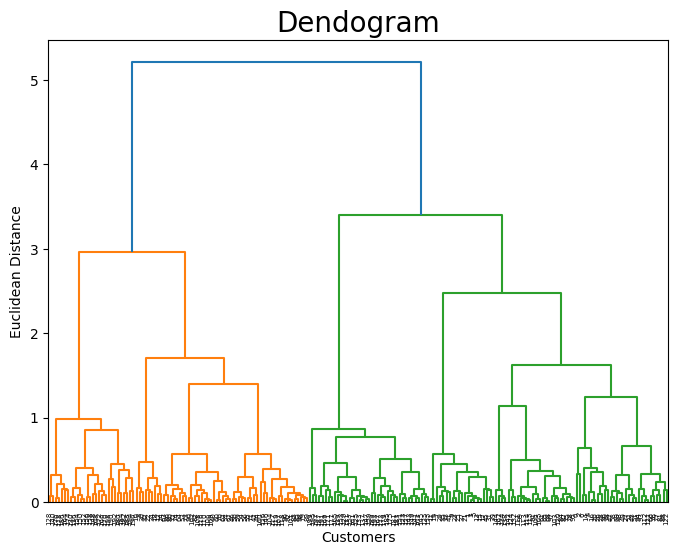

In [ ]:
# 13.

import scipy.cluster.hierarchy as sch

plt.rcParams['figure.figsize'] = (8, 6)

dendrogram = sch.dendrogram(sch.linkage(df_scaled, method = 'ward'))
plt.title('Dendogram', fontsize = 20)
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.show()

The optimal number of clusters by looking for the longest vertical line that is not intersected by any horizontal line is 5.

In [ ]:
# 14.

from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
import pandas as pd

pca = PCA(n_components=2)
df_pca_2d = pca.fit_transform(df_scaled)

data_pca_2d_df = pd.DataFrame(df_pca_2d, columns=['PC1', 'PC2'])


agg_clustering = AgglomerativeClustering(n_clusters = 5, linkage = 'ward')
clusters_2d = agg_clustering.fit_predict(data_pca_2d_df)

data_pca_2d_df['Cluster'] = pd.DataFrame(clusters_2d)

data_pca_2d_df['Cluster'] = data_pca_2d_df['Cluster'].apply(lambda x: f'Cluster {x}')

data_pca_2d_df = data_pca_2d_df.sort_values('Cluster')

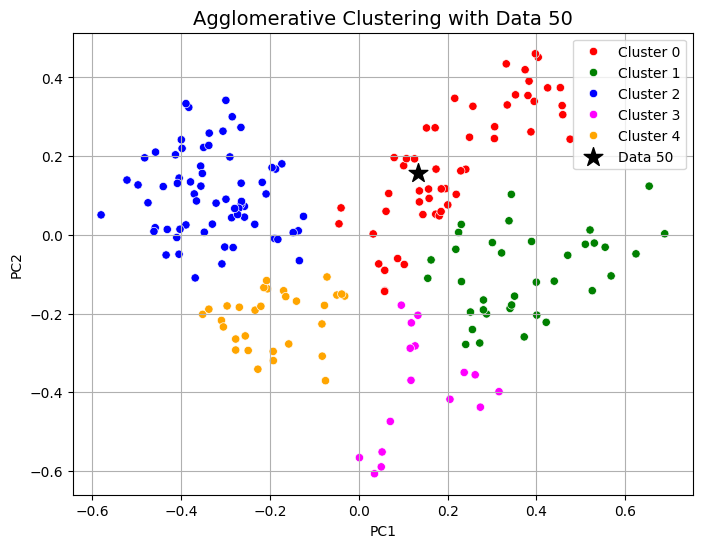

In [ ]:
# a. Visualize the x = PC0 and y = PC1, Show Data 50 with marker of star (*) using 2D scatter plot

plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=data_pca_2d_df, palette=['red','green','blue','magenta','orange'])

data_50_pc1 = data_pca_2d_df.loc[50, 'PC1']
data_50_pc2 = data_pca_2d_df.loc[50, 'PC2']

plt.scatter(data_50_pc1, data_50_pc2, marker='*', s=200, c='black', label='Data 50')

plt.title('Agglomerative Clustering with Data 50', fontsize=14)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# b. Visualize the x = PC0, y = PC1, and z = PC2, Show or Trace Data 50 with black circle, using scatter_3D.

from sklearn.decomposition import PCA
import pandas as pd
import plotly.express as px

pca_3d = PCA(n_components=3)
df_pca_3d = pca_3d.fit_transform(df_scaled)

data_pca_3d_df = pd.DataFrame(df_pca_3d, columns=['PC1', 'PC2', 'PC3'])

data_pca_3d_df['Cluster'] = clusters_2d

data_pca_3d_df['Cluster'] = data_pca_3d_df['Cluster'].apply(lambda x: f'Cluster {x}')

fig = px.scatter_3d(data_pca_3d_df, x='PC1', y='PC2', z='PC3', color='Cluster',
                    title='Agglomerative Clustering (3D PCA)')
data_50_3d = data_pca_3d_df.loc[49]

fig.add_scatter3d(x=[data_50_3d['PC1']], y=[data_50_3d['PC2']], z=[data_50_3d['PC3']],
                  mode='markers',
                  marker=dict(
                      color='black',
                      size=10,
                      symbol='circle'
                  ),
                  name='Data 50')

fig.show()

print(f"Data 50 belongs to Cluster: {clusters_2d[50]}")

Data 50 belongs to Cluster: 0


## Key Findings: Mall Customer Segmentation

This analysis grouped mall customers based on their age, income, and spending habits:

*   **Data Prepared**: Customer data was cleaned and scaled for fair comparison.
*   **Key Information Captured**: PCA confirmed that 3 main factors (PC1, PC2, PC3) explain almost all variations in customer behavior.
*   **5 Customer Groups Found**: A dendrogram (data family tree) showed that customers naturally fall into 5 distinct groups.
*   **Visualized Clusters**: We saw these 5 groups clearly in both 2D and 3D plots, with 'Data Point 50' belonging to 'Cluster 0'.

**In short, I've identified 5 different types of mall customers based on their financial and age-related behaviors.**